# Income predictor for employed newcomers in Canada-Ontario

This notebook trains an **XGBoost Regressor** to predict annual income for newcomers who are already employed.

It mirrors the label-encoding approach used in `model_training.ipynb` (the employment classifier), so the two notebooks are fully consistent.

## Step 1 — Install & Import Libraries

In [1]:
# !pip install xgboost shap scikit-learn pandas matplotlib joblib

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

## Step 2 — Load the Dataset
We load the full CSV, then immediately filter to **employed == 1** because we only predict income for people who are working.

In [2]:
DATA_PATH = 'newcomer_ontario_enriched.csv'

df = pd.read_csv(DATA_PATH)
print(f'Full dataset: {df.shape[0]} rows × {df.shape[1]} columns')

df.head()

Full dataset: 6900 rows × 26 columns


,age,sex,admission_category,province,world_region,speaks_official_language,education_level,family_size,field_of_study,previous_occupation,...,employed,employment_category,employment_occupation,employment_sector,occupationally_downgraded,annual_income,months_to_employment,rent_to_income_ratio,housing_affordable,affordability_score
0,35,M,Skilled Worker,Ontario,South Asia,1,University,1,Economics,HR Specialist,...,1,Sales & Service,Cashier,Accommodation & Food Services,1,21900.0,7,1.15,0,0.436
1,43,M,Skilled Worker,Ontario,South Asia,0,High School,4,General Studies,Administrative Officer,...,1,"Business, Finance & Administration",Accountant,Public Administration,0,63300.0,2,0.40,0,0.706
2,33,M,Skilled Worker,Ontario,South Asia,1,University,3,Business Administration,Administrative Officer,...,1,"Business, Finance & Administration",Administrative Officer,Professional Services,0,91400.0,2,0.28,1,0.861
3,42,M,Skilled Worker,Ontario,South Asia,1,College,3,Business Administration,Restaurant Manager,...,1,Management,Restaurant Manager,Accommodation & Food Services,0,78000.0,4,0.32,0,0.800
4,27,M,Skilled Worker,Ontario,South Asia,1,University,1,Mathematics,Mechanical Engineer,...,1,"Trades, Transport & Equipment Operators",Electrician,Construction,1,31300.0,1,0.81,0,0.511


## Step 3 — Filter to Employed Newcomers Only

In [3]:
# Keep only rows where the person is employed
df_employed = df[df['employed'] == 1].copy()

print(f'Rows after filtering to employed == 1: {len(df_employed)}')
print(f'Rows removed (not employed)          : {len(df) - len(df_employed)}')

Rows after filtering to employed == 1: 5390
Rows removed (not employed)          : 1510


In [4]:
df.columns

Index(['age', 'sex', 'admission_category', 'province', 'world_region',
       'speaks_official_language', 'education_level', 'family_size',
       'field_of_study', 'previous_occupation', 'occupation_category',
       'years_of_experience', 'teer_category', 'credential_recognition_status',
       'regulated_profession', 'employment_probability', 'employed',
       'employment_category', 'employment_occupation', 'employment_sector',
       'occupationally_downgraded', 'annual_income', 'months_to_employment',
       'rent_to_income_ratio', 'housing_affordable', 'affordability_score'],
      dtype='object')

## Step 4 — Select Features and Target
We use **14 features** that are known before a person starts working — no post-employment leakage.

| Feature | Type |
|---|---|
| age | numerical |
| sex | categorical |
| admission_category | categorical |
| world_region | categorical |
| speaks_official_language | binary |
| education_level | categorical |
| family_size | numerical |
| field_of_study | categorical |
|previous_occupation | categorical |
|employment_category | categorical |
| years_of_experience | numerical |
| teer_category | categorical|
| credential_recognition_status | categorical |
|regulated_profession | binary |


## Step 5 — Label Encode Categorical Columns
XGBoost needs numbers, not text. `LabelEncoder` converts each unique string to an integer (e.g. `'Female'` → `0`, `'Male'` → `1`).

> This uses the **same approach** as `Secondversion_XGB_classifier.ipynb` so the two notebooks stay consistent.

In [5]:
# Make a copy so we do not modify the original dataframe
df_processed = df.copy()

# Drop the province column because every row is Ontario, so it adds no useful information
df_processed.drop(columns=["province"], inplace=True)

# Scope down to the 14 features selected for the regressor.
regressor_features = [
    "age",
    "sex",
    "admission_category",
    "world_region",
    "speaks_official_language",
    "education_level",
    "family_size",
    "field_of_study",
    "previous_occupation",
    "employment_category",
    "years_of_experience",
    "teer_category",
    "credential_recognition_status",
    "regulated_profession",
]
Target = "annual_income"

df_processed = df_processed[regressor_features + [Target]]

# collapse rare categories into "Other" for the two high-cardinality features
high_cardinality_features = ["previous_occupation", "field_of_study"]
rare_threshold = 0.01  # this collapse categories below 1% frequency

rare_category_map = {}
for col in high_cardinality_features:
    freq = df_processed[col].value_counts(normalize=True)
    rare_categories = freq[freq < rare_threshold].index.tolist()
    rare_category_map[col] = rare_categories
    df_processed[col] = df_processed[col].where(~df_processed[col].isin(rare_categories), "Other")
    print(f"{col}: collapsed {len(rare_categories)} rare categories into 'Other' "
          f"-> {df_processed[col].nunique()} categories remaining")

#Label encode all 9 categorical columns
categorical_cols = [
    "sex",
    "admission_category",
    "world_region",
    "education_level",
    "field_of_study",
    "previous_occupation",
    "employment_category",
    "teer_category",
    "credential_recognition_status",
]

label_encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    df_processed[col] = encoder.fit_transform(df_processed[col])
    label_encoders[col] = encoder
    print(f"Encoded '{col}' column.")

print(f"Processed dataframe shape: {df_processed.shape}")

df_processed.head()

previous_occupation: collapsed 4 rare categories into 'Other' -> 38 categories remaining
field_of_study: collapsed 8 rare categories into 'Other' -> 27 categories remaining
Encoded 'sex' column.
Encoded 'admission_category' column.
Encoded 'world_region' column.
Encoded 'education_level' column.
Encoded 'field_of_study' column.
Encoded 'previous_occupation' column.
Encoded 'employment_category' column.
Encoded 'teer_category' column.
Encoded 'credential_recognition_status' column.
Processed dataframe shape: (6900, 15)


,age,sex,admission_category,world_region,speaks_official_language,education_level,family_size,field_of_study,previous_occupation,employment_category,years_of_experience,teer_category,credential_recognition_status,regulated_profession,annual_income
0,35,1,6,3,1,3,1,4,15,8,8,1,2,0,21900.0
1,43,1,6,3,0,1,4,9,1,1,20,1,0,0,63300.0
2,33,1,6,3,1,3,3,1,1,1,2,1,0,0,91400.0
3,42,1,6,3,1,0,3,1,29,4,15,0,0,0,78000.0
4,27,1,6,3,1,3,1,17,19,9,2,1,1,0,31300.0


## Step 6 — Train / Test Split

In [6]:
#Define X and y
X = df_processed[regressor_features]
y = df_processed[Target]

In [7]:
# Split the data into 80% training and 20% testing
# stratify=y ensures the class balance is preserved in both splits
# random_state=42 makes the split reproducible

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")

Training set size: 5520 samples
Test set size:     1380 samples


In [8]:
# Linear Regression Baseline model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²:", round(linear_r2, 3))

Linear Regression Results
MAE: 22727.99
RMSE: 28142.93
R²: 0.409


## Step 7 — Train XGBoost Regressor
`XGBRegressor` builds an ensemble of decision trees that learn to predict a continuous number (income). Using `random_state=42` keeps results reproducible.

In [9]:
model = XGBRegressor(random_state=42, verbosity=0)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## Step 8 — Evaluate the Model
Three standard regression metrics:

| Metric | What it tells you |
|---|---|
| **MAE** | Average dollar error — easy to interpret |
| **RMSE** | Like MAE but penalises large errors more |
| **R²** | How much variance the model explains (1.0 = perfect) |

In [15]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('Model Evaluation on Test Set')
print('─' * 40)
print(f'MAE  (Mean Absolute Error) : ${mae:,.0f}')
print(f'MSE (Mean Squared Error) : ${mse:,.0f}')
print(f'RMSE (Root Mean Sq. Error) : ${rmse:,.0f}')
print(f'R²   Score                 : {r2:.3f}')

Model Evaluation on Test Set
────────────────────────────────────────
MAE  (Mean Absolute Error) : $9,037
MSE (Mean Squared Error) : $166,354,657
RMSE (Root Mean Sq. Error) : $12,898
R²   Score                 : 0.876


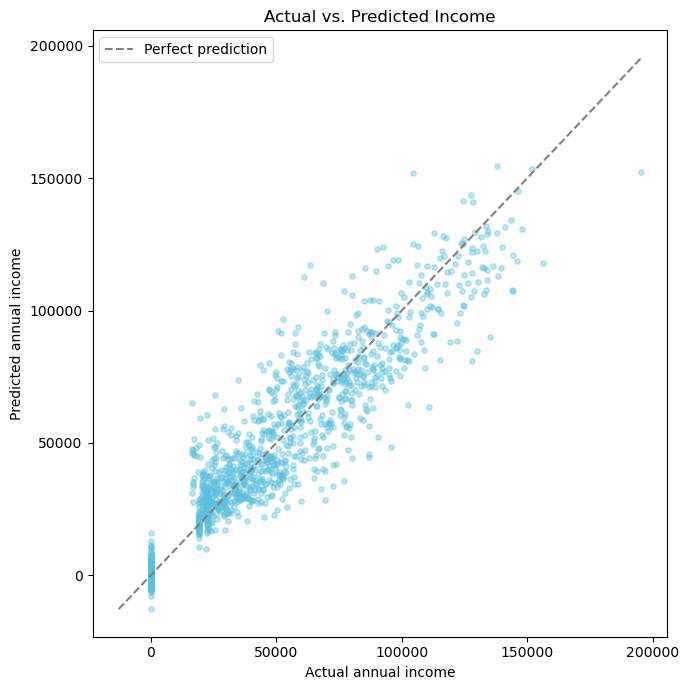

In [16]:
#compares the predicted annual incomes with the actual values in the test dataset
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="#5bc0de")

# perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray", label="Perfect prediction")

ax.set_xlabel("Actual annual income")
ax.set_ylabel("Predicted annual income")
ax.set_title("Actual vs. Predicted Income")
ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted_income.png", dpi=150)
plt.show()

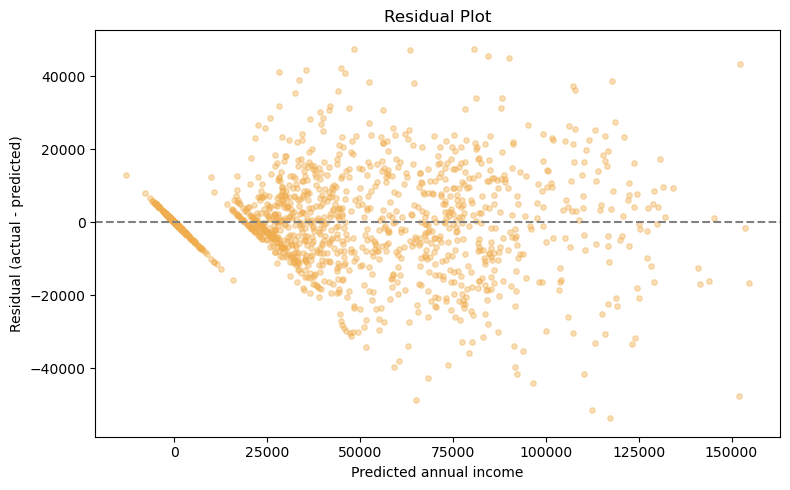

In [17]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.4, s=15, color="#f0ad4e")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("Predicted annual income")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residual Plot")
plt.tight_layout()
plt.savefig("residual_plot_income.png", dpi=150)
plt.show()

In [11]:
# Compare Linear Regression and XGBoost Regressor

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost Regressor"],
    "MAE": [linear_mae, mae],
    "RMSE": [linear_rmse, rmse],
    "R2": [linear_r2, r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,22727.994826,28142.928798,0.409318
1,XGBoost Regressor,9036.959695,12897.854743,0.875935


## Step 9 — SHAP Waterfall Chart
SHAP (**SH**apley **A**dditive ex**P**lanations) explains *why* the model predicted a specific value for one person.

The waterfall chart shows each feature's **push** (red, +) or **pull** (blue, −) on the predicted income, starting from the model's average output (`E[f(X)]`).

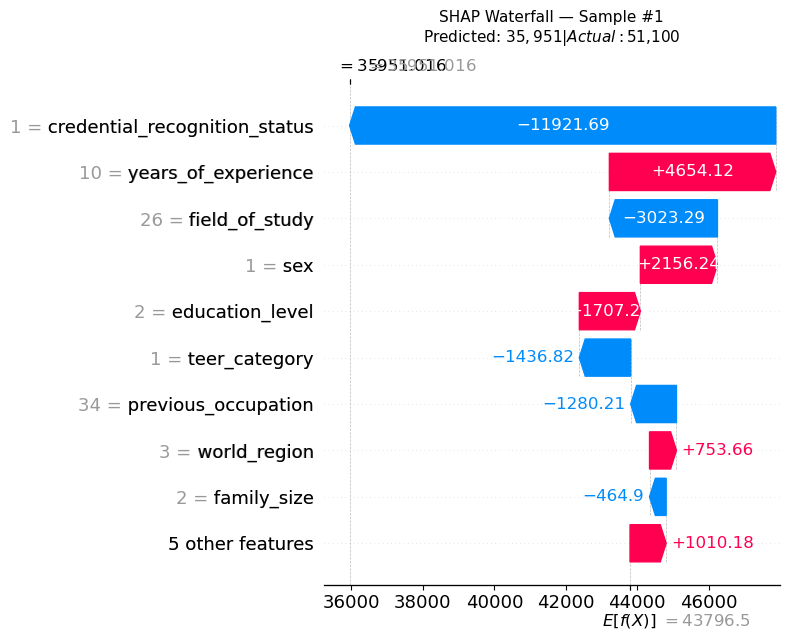

In [12]:
# Build a SHAP explainer from the trained model
explainer = shap.Explainer(model)

# Compute SHAP values for the whole test set
shap_values = explainer(X_test)

# Waterfall chart for the first test sample
first_idx = 0

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[first_idx], show=False)

plt.title(
    f'SHAP Waterfall — Sample #1\n'
    f'Predicted: ${y_pred[first_idx]:,.0f}  |  Actual: ${y_test.iloc[first_idx]:,.0f}',
    fontsize=11, pad=12
)
plt.tight_layout()

SHAP_PATH = 'income_shap.png'
plt.savefig(SHAP_PATH, dpi=150, bbox_inches='tight')
plt.show()


## Step 10 — Save the Trained Model

In [13]:
os.makedirs('models', exist_ok=True)
MODEL_PATH = 'Secondversion_XGB_regressor.pkl'

joblib.dump(model, MODEL_PATH)


['Secondversion_XGB_regressor.pkl']